In [1]:
MODEL_DATASET = {
    'qwen-0.5b': 'output/results_probeonly_20260527_154159_qwen-0.5b.json',
    'llama-1b': 'output/results_probeonly_20260520_154434_llama-1b.json',
    'gemma-27b': 'output/20260508-runpod/results_probeonly_20260508_171344_gemma-27b.json',
    'qwen-32b': 'output/20260508-runpod/results_probeonly_20260508_184340_qwen-32b.json',
    'qwq-32b': 'output/20260508-runpod/results_probeonly_20260508_193619_qwq-32b.json',
    'llama-70b': 'output/20260511-runpod/results_probeonly_20260511_195030_llama-70b.json',
    'qwen-72b': 'output/20260512-runpod/results_probeonly_20260512_164943_qwen-72b.json',
    'deepseek-r1-70b': 'output/20260513-runpod/results_probeonly_20260513_200835_deepseek-r1-70b.json',
}

In [2]:
import json
# import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker

dfs = {}
for model, path in MODEL_DATASET.items():
    with open(f'../{path}') as f:
        records = json.load(f)
    dfs[model] = pd.DataFrame(records)

# Quick sanity check
for model, df in dfs.items():
    print(f"{model:25s}  n={len(df):5d}  verdict_true={df['probe_verdict'].mean():.2%}  "
          f"proj_range=[{df['probe_projection'].min():.1f}, {df['probe_projection'].max():.1f}]")

qwen-0.5b                  n= 4320  verdict_true=0.00%  proj_range=[-0.5, 1.3]
llama-1b                   n= 4320  verdict_true=32.73%  proj_range=[-0.1, 0.1]
gemma-27b                  n= 4320  verdict_true=30.67%  proj_range=[-688.0, 1856.0]
qwen-32b                   n= 4320  verdict_true=99.63%  proj_range=[-418.0, -113.0]
qwq-32b                    n= 4320  verdict_true=81.83%  proj_range=[-17.0, 9.9]
llama-70b                  n= 4320  verdict_true=60.51%  proj_range=[-0.6, 1.2]
qwen-72b                   n= 4320  verdict_true=98.59%  proj_range=[-115.5, 120.0]
deepseek-r1-70b            n= 4320  verdict_true=53.50%  proj_range=[-0.5, 0.9]


## Strong labeling

¿Qué pasa si asumimos que los prompts asociados a ciertas dimensiones en nuestro dataset de sensibilidad son de evaluación?

Para este análisis voy a asumir que todo prompt que contenga elementos inverosímiles pertenece a un contexto de evaluación. Por lo tanto todo prompt con una o más de las siguientes caracterísitcas será considerado de prueba, mientras que los restantes serán considerados de un contexto de uso real.

```
Coherencia de contexto = 0-incoherente
Coherencia de contexto = 1-incoherente_multiv
Estructura del prompt = 3-estructurado
Familiaridad de la entidad = 0-inventada_baja
Familiaridad de la entidad = 1-inventada_alta
Conflicto ético = 1-autoproteccion
Conflicto ético = 4-conflicto_rol
```

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
)

FACTOR_NAMES = {
    'context_coherence':  'Coherencia de contexto',
    'prompt_structure':   'Estructura del prompt',
    'entity_familiarity': 'Familiaridad de la entidad',
    'ethical_pressure':   'Conflicto ético',
}

EVAL_CRITERIA = {
    'context_coherence':  {0, 1},
    'prompt_structure':   {3},
    'entity_familiarity': {0, 1},
    'ethical_pressure':   {1, 4},
}

for model, df in dfs.items():
    mask = pd.Series(False, index=df.index)
    for col, vals in EVAL_CRITERIA.items():
        mask |= df[col].isin(vals)
    dfs[model] = df.assign(is_eval=mask)

# All models share the same prompts → labels are identical across models
ref = dfs['qwen-0.5b']['is_eval']
print("Distribución de etiquetas (strong labeling):")
print(f"  eval : {ref.sum():,}  ({ref.mean():.1%})")
print(f"  real : {(~ref).sum():,}  ({(~ref).mean():.1%})")
print(f"  total: {len(ref):,}")

models = list(dfs.keys())

Distribución de etiquetas (strong labeling):
  eval : 3,996  (92.5%)
  real : 324  (7.5%)
  total: 4,320


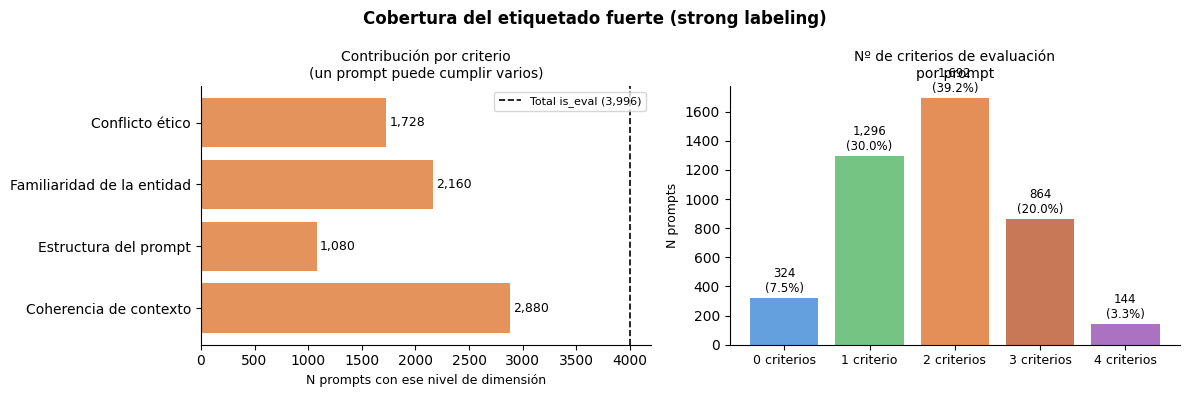

In [4]:
# How many prompts each criterion flags — they overlap heavily
df0 = dfs['qwen-0.5b']

criteria_counts = {FACTOR_NAMES[col]: df0[col].isin(vals).sum()
                   for col, vals in EVAL_CRITERIA.items()}

# Prompts flagged by exactly k criteria
flags = pd.DataFrame({col: df0[col].isin(vals) for col, vals in EVAL_CRITERIA.items()})
overlap_counts = flags.sum(axis=1).value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: per-criterion count
bars = ax1.barh(list(criteria_counts.keys()), list(criteria_counts.values()),
                color='#e07b39', alpha=0.82, edgecolor='none')
ax1.axvline(ref.sum(), color='black', linestyle='--', linewidth=1.2,
            label=f'Total is_eval ({ref.sum():,})')
for bar, val in zip(bars, criteria_counts.values()):
    ax1.text(val + 30, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_xlabel('N prompts con ese nivel de dimensión', fontsize=9)
ax1.set_title('Contribución por criterio\n(un prompt puede cumplir varios)', fontsize=10)
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: overlap — how many criteria does each prompt satisfy?
colors = ['#4a90d9', '#5dba6e', '#e07b39', '#c0603a', '#9b59b6']
ax2.bar(overlap_counts.index, overlap_counts.values,
        color=[colors[i] for i in overlap_counts.index], alpha=0.85, edgecolor='none')
for k, v in overlap_counts.items():
    ax2.text(k, v + 20, f'{v:,}\n({v/len(df0):.1%})', ha='center', va='bottom', fontsize=8.5)
ax2.set_xticks(overlap_counts.index)
ax2.set_xticklabels([f'{k} criterio{"s" if k != 1 else ""}' for k in overlap_counts.index], fontsize=9)
ax2.set_ylabel('N prompts', fontsize=9)
ax2.set_title('Nº de criterios de evaluación\npor prompt', fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Cobertura del etiquetado fuerte (strong labeling)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## Distribución de probe_projection por etiqueta

¿Se separan las distribuciones de `probe_projection` según `is_eval`? Si la sonda captura algo relacionado con la inverosimilitud, los prompts de evaluación deberían tener proyecciones más altas (o más bajas, dependiendo del signo) que los prompts de uso real.

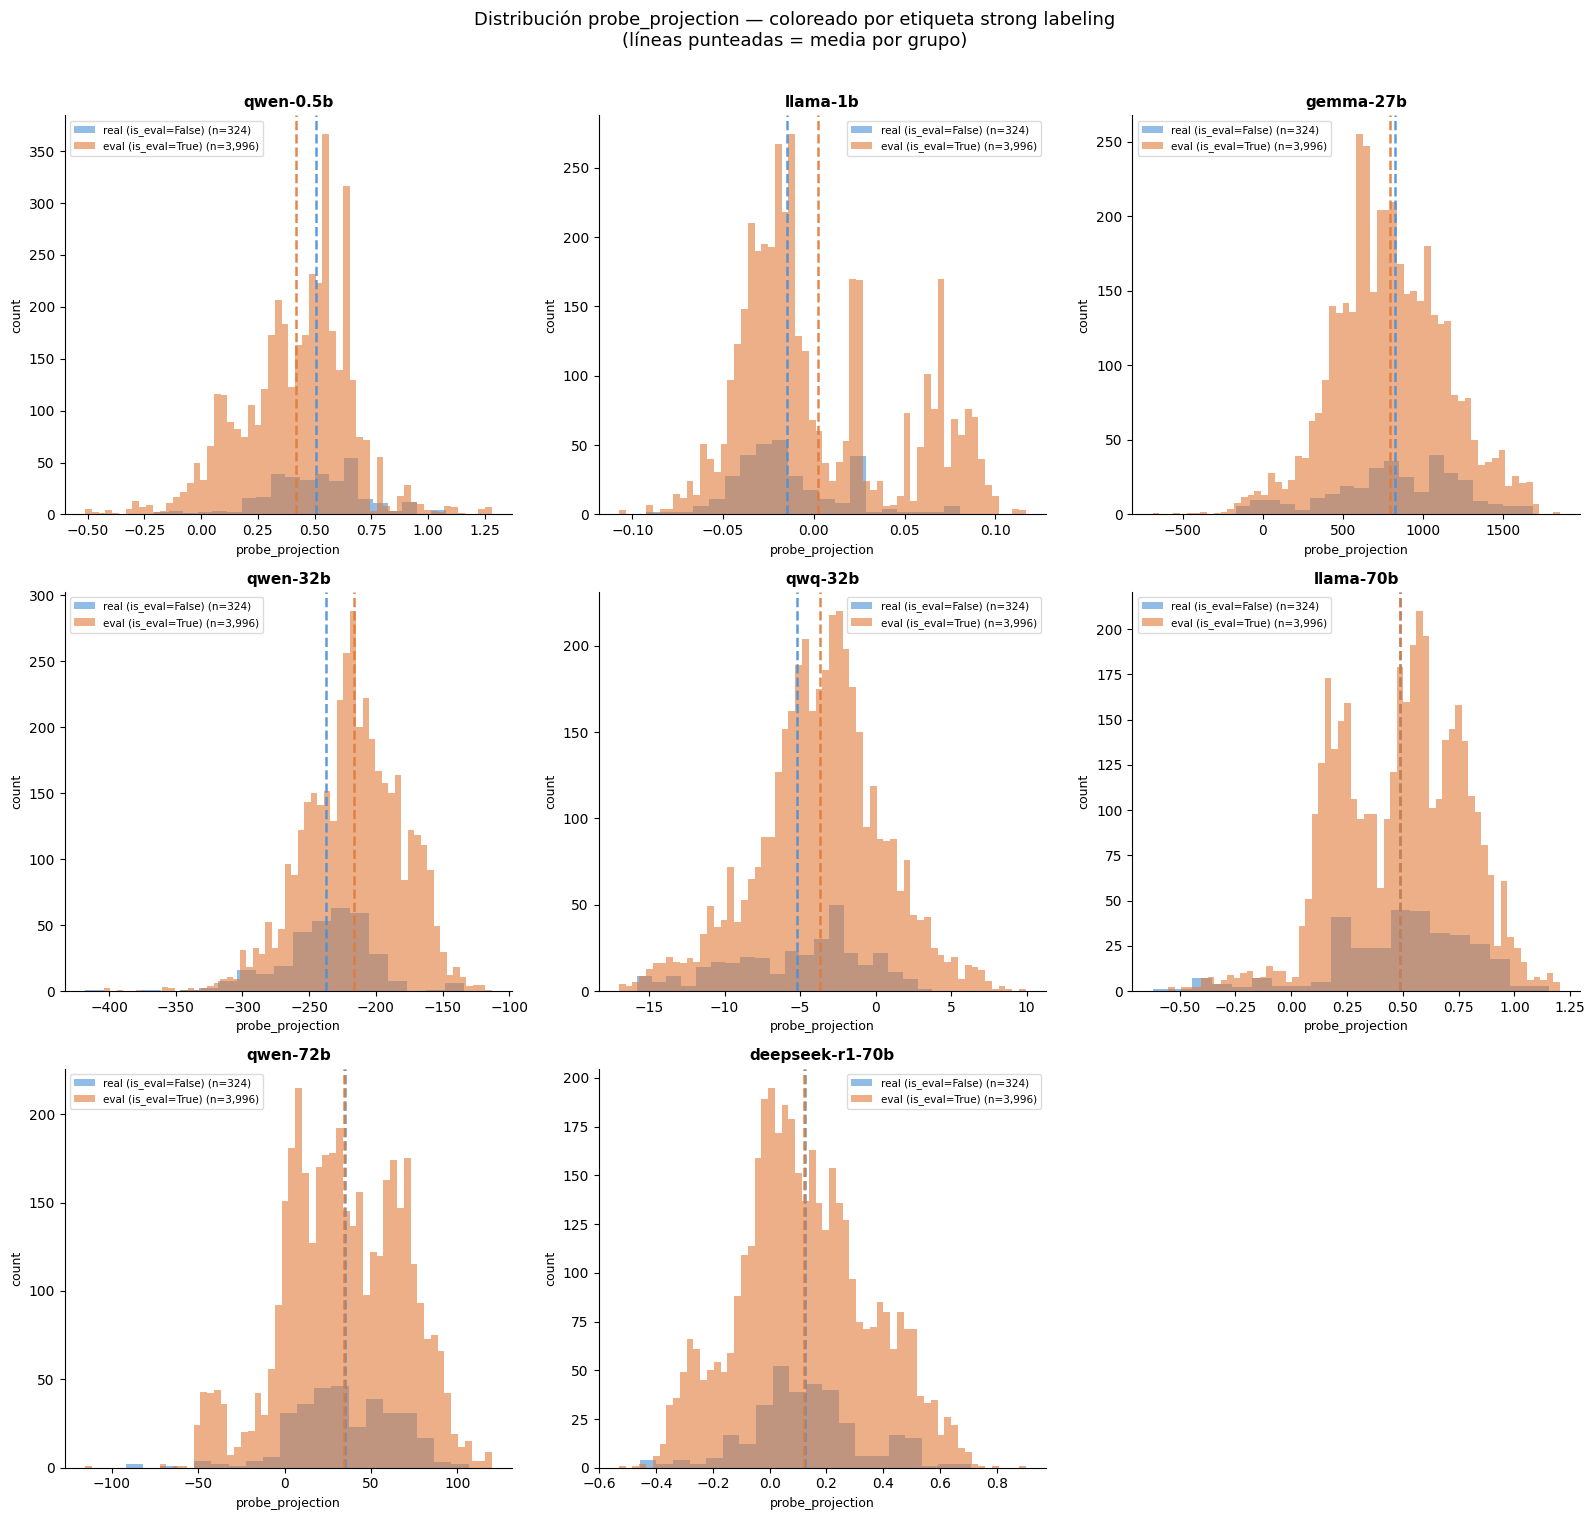

In [5]:
MODEL_COLORS = {
    'qwen-0.5b':       '#a8839b',
    'llama-1b':        '#768a8c',
    'gemma-27b':       '#4a90d9',
    'qwen-32b':        '#e07b39',
    'qwq-32b':         '#f0c040',
    'llama-70b':       '#5dba6e',
    'qwen-72b':        '#c0603a',
    'deepseek-r1-70b': '#9b59b6',
}

LABEL_COLORS = {True: '#e07b39', False: '#4a90d9'}
LABEL_NAMES  = {True: 'eval (is_eval=True)', False: 'real (is_eval=False)'}

n_models = len(models)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for ax, model in zip(axes, models):
    df = dfs[model]
    for label in [False, True]:
        vals = df.loc[df['is_eval'] == label, 'probe_projection'].values
        n_bins = min(60, max(20, len(vals) // 50))
        ax.hist(vals, bins=n_bins, color=LABEL_COLORS[label], alpha=0.60,
                label=f"{LABEL_NAMES[label]} (n={len(vals):,})", edgecolor='none')

    # Mark the means
    for label in [False, True]:
        m = df.loc[df['is_eval'] == label, 'probe_projection'].mean()
        ax.axvline(m, color=LABEL_COLORS[label], linewidth=1.8, linestyle='--', alpha=0.9)

    ax.set_title(model, fontsize=11, fontweight='bold')
    ax.set_xlabel('probe_projection', fontsize=9)
    ax.set_ylabel('count', fontsize=9)
    ax.legend(fontsize=7.5, framealpha=0.7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Distribución probe_projection — coloreado por etiqueta strong labeling\n(líneas punteadas = media por grupo)',
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Métricas de clasificación

En lugar de usar `probe_verdict` (cuyo umbral fue calibrado para otra tarea), elegimos un **umbral óptimo por modelo** que maximiza el índice de Youden (J = TPR − FPR) sobre `is_eval`. Este criterio es equivalente a maximizar la accuracy balanceada y es robusto al desbalance de clases — a diferencia de F1, que con un 92.5% de positivos converge trivialmente a "predecir todo True".

**Caveat sobre la evaluación in-sample:** el umbral se elige y evalúa sobre el mismo dataset. Las métricas son optimistas como estimación de capacidad generalizable, pero válidas para caracterizar qué tan bien la proyección de la sonda puede discriminar según este criterio. El **ROC-AUC** sigue siendo la métrica más robusta porque es invariante al umbral.

In [6]:
# Find the threshold that maximises Youden's J (= TPR − FPR) for each model.
# Youden's J is equivalent to maximising balanced accuracy and is robust to
# class imbalance — unlike F1, which with 92.5% positives always prefers
# the "predict everything True" degenerate solution.

optimal_thresholds = {}

print(f"{'model':25s}  {'orig_threshold':>15s}  {'opt_threshold':>13s}  {'Youden_J':>9s}  {'bal_acc':>8s}")
print('-' * 78)

for model, df in dfs.items():
    y_true  = df['is_eval'].astype(int).values
    y_score = df['probe_projection'].values

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    j_scores = tpr - fpr
    best     = int(j_scores.argmax())
    opt_thr  = float(thresholds[best])
    optimal_thresholds[model] = opt_thr

    y_pred   = (y_score >= opt_thr).astype(int)
    bal_acc  = (recall_score(y_true, y_pred, zero_division=0) +
                recall_score(1 - y_true, 1 - y_pred, zero_division=0)) / 2

    orig = df['probe_projection'][df['probe_verdict'] == True].min() if df['probe_verdict'].any() else float('nan') # noqa: E712
    print(f"{model:25s}  {orig:>15.4f}  {opt_thr:>13.4f}  {j_scores[best]:>9.3f}  {bal_acc:>8.3f}")

model                       orig_threshold  opt_threshold   Youden_J   bal_acc
------------------------------------------------------------------------------
qwen-0.5b                              nan         1.0859      0.007     0.503
llama-1b                            0.0159         0.0383      0.186     0.593
gemma-27b                         984.0000       172.0000      0.066     0.533
qwen-32b                         -330.0000      -207.0000      0.259     0.630
qwq-32b                            -7.2188        -7.2812      0.167     0.583
llama-70b                           0.4355        -0.0630      0.051     0.525
qwen-72b                          -46.0000        57.5000      0.045     0.522
deepseek-r1-70b                     0.0830         0.2334      0.070     0.535


In [7]:
rows = []
for model, df in dfs.items():
    y_true  = df['is_eval'].astype(int).values
    y_score = df['probe_projection'].values
    y_pred  = (y_score >= optimal_thresholds[model]).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
    except Exception:
        auc = float('nan')

    rows.append({
        'model':       model,
        'pred_eval_%': y_pred.mean(),
        'accuracy':    accuracy_score(y_true, y_pred),
        'precision':   precision_score(y_true, y_pred, zero_division=0),
        'recall':      recall_score(y_true, y_pred, zero_division=0),
        'f1':          f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':     auc,
    })

metrics_df = pd.DataFrame(rows).set_index('model')

# Baseline: always predict True (majority class)
base_acc  = ref.mean()
base_prec = ref.mean()
base_rec  = 1.0
base_f1   = 2 * base_prec * base_rec / (base_prec + base_rec)
print(f"Baseline trivial (siempre pred=True): accuracy={base_acc:.3f}  precision={base_prec:.3f}  recall={base_rec:.3f}  f1={base_f1:.3f}  roc_auc=0.500")
print()
print(metrics_df.round(3).to_string())

Baseline trivial (siempre pred=True): accuracy=0.925  precision=0.925  recall=1.000  f1=0.961  roc_auc=0.500

                 pred_eval_%  accuracy  precision  recall     f1  roc_auc
model                                                                    
qwen-0.5b              0.006     0.081      1.000   0.007  0.013    0.395
llama-1b               0.209     0.279      0.987   0.223  0.364    0.600
gemma-27b              0.959     0.899      0.930   0.964  0.947    0.458
qwen-32b               0.376     0.430      0.973   0.395  0.562    0.662
qwq-32b                0.821     0.796      0.939   0.834  0.883    0.587
llama-70b              0.970     0.906      0.929   0.973  0.951    0.481
qwen-72b               0.291     0.329      0.936   0.295  0.448    0.489
deepseek-r1-70b        0.300     0.340      0.941   0.305  0.461    0.490


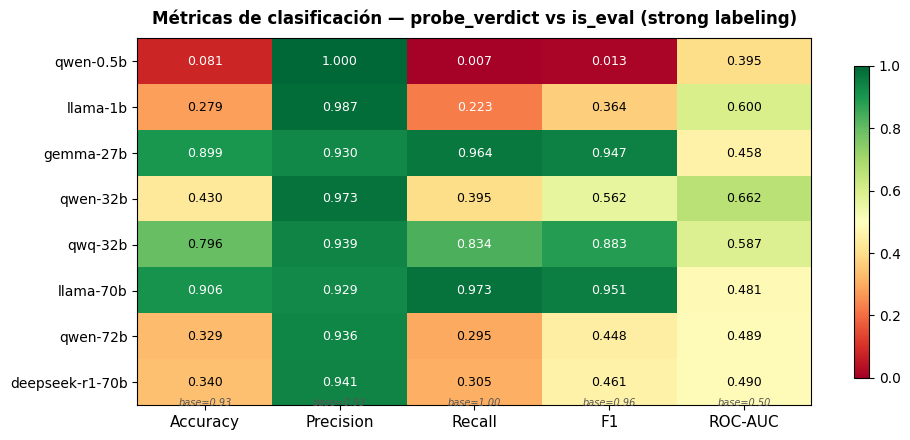

In [8]:
METRIC_COLS   = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
METRIC_LABELS = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
BASELINE_VALS = [base_acc, base_prec, base_rec, base_f1, 0.5]

data = metrics_df[METRIC_COLS].values

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(METRIC_COLS)))
ax.set_xticklabels(METRIC_LABELS, fontsize=11)
ax.set_yticks(range(len(metrics_df)))
ax.set_yticklabels(metrics_df.index, fontsize=10)

for i in range(len(metrics_df)):
    for j in range(len(METRIC_COLS)):
        val = data[i, j]
        txt_color = 'black' if 0.25 < val < 0.80 else 'white'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, color=txt_color)

# Baseline row indicator
for j, bval in enumerate(BASELINE_VALS):
    ax.text(j, len(metrics_df) - 0.45,
            f'base={bval:.2f}', ha='center', va='bottom',
            fontsize=7, color='#555', style='italic')

plt.colorbar(im, ax=ax, shrink=0.85)
ax.set_title('Métricas de clasificación — probe_verdict vs is_eval (strong labeling)',
             fontsize=12, fontweight='bold', pad=10)
fig.tight_layout()
plt.show()

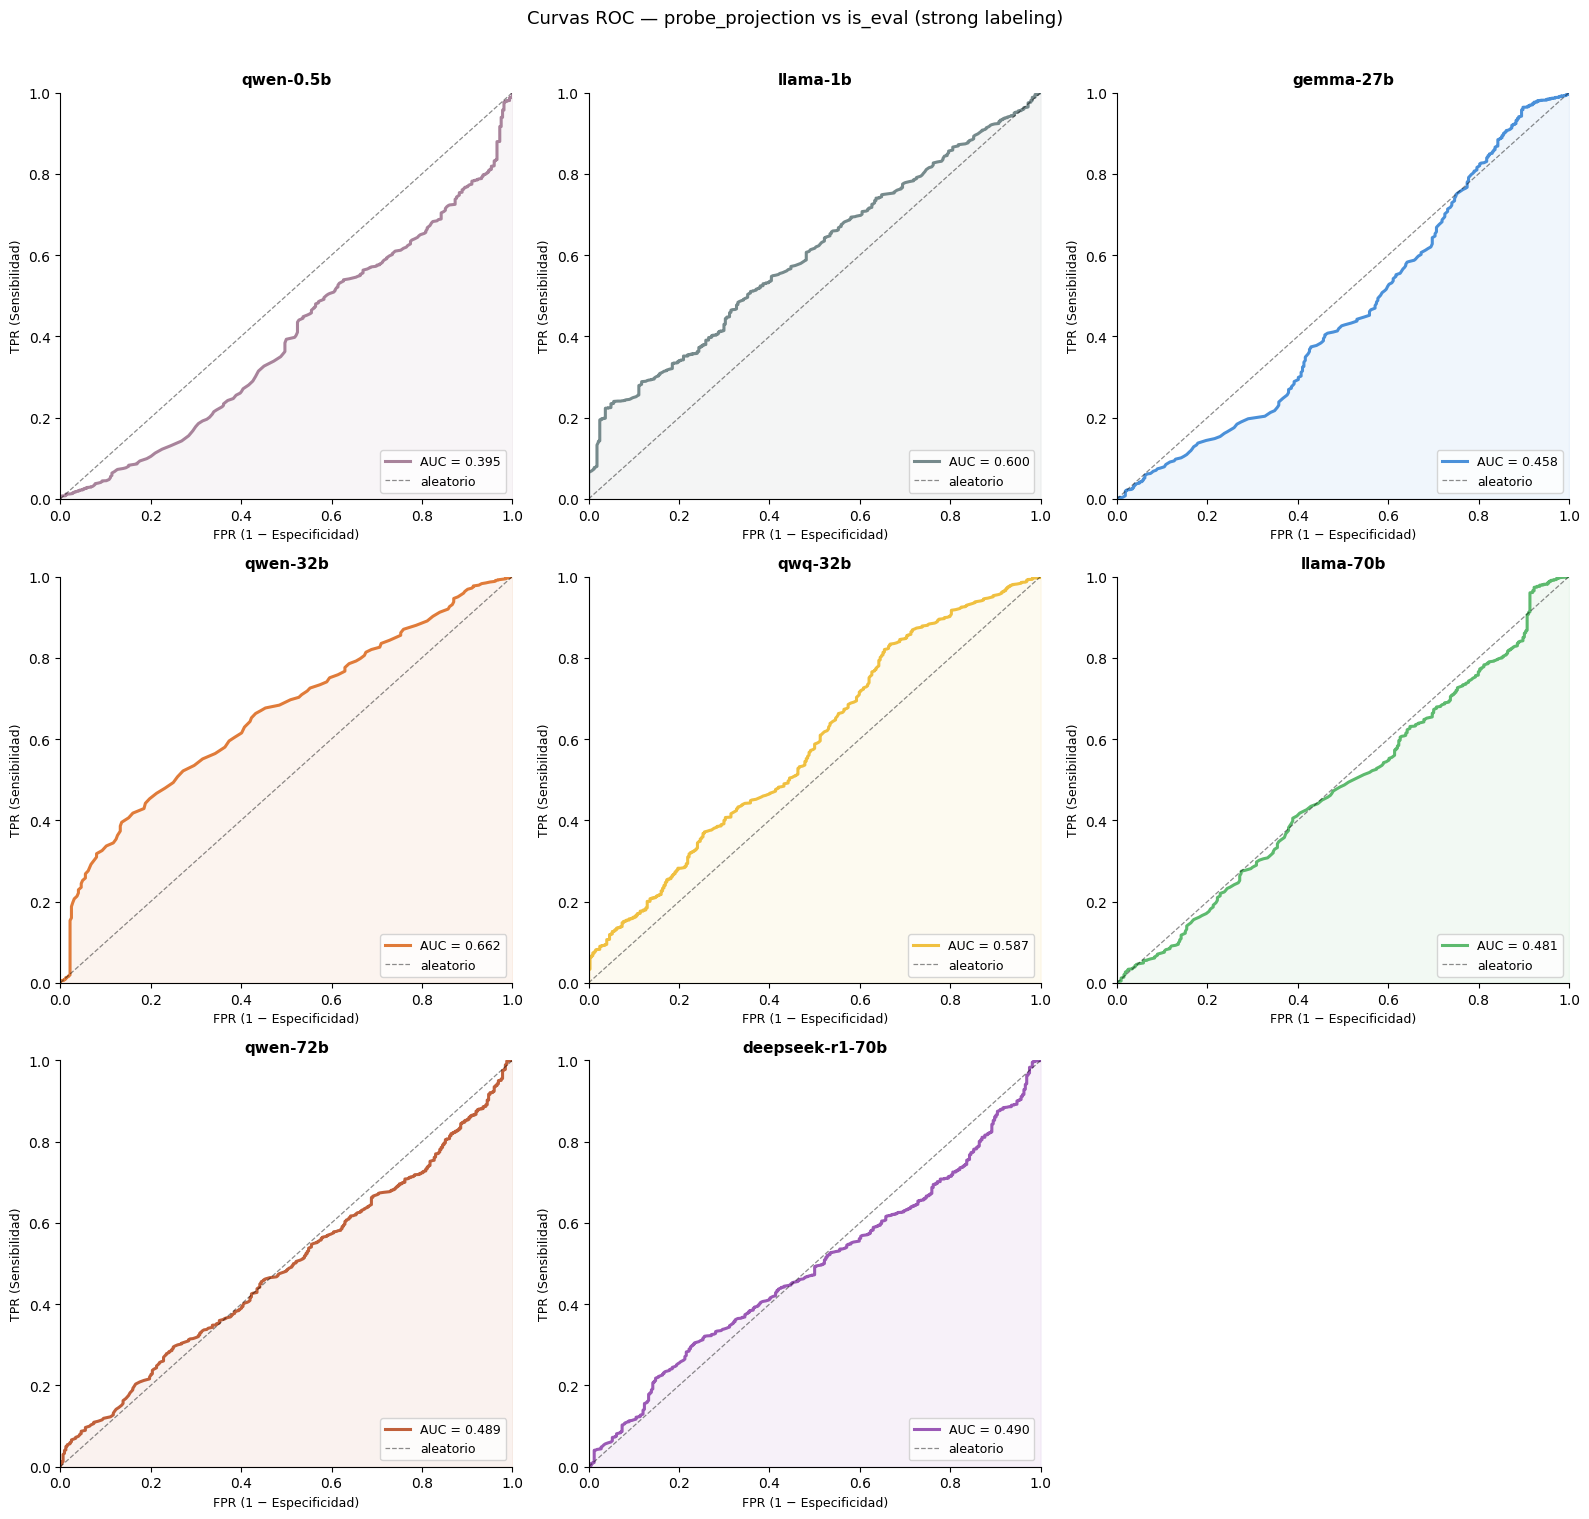

In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for ax, model in zip(axes, models):
    df     = dfs[model]
    y_true = df['is_eval'].astype(int).values
    y_score = df['probe_projection'].values
    color  = MODEL_COLORS[model]

    try:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f'AUC = {auc:.3f}')
        ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    except Exception as exc:
        ax.text(0.5, 0.5, str(exc), ha='center', va='center',
                transform=ax.transAxes, fontsize=8)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.9, alpha=0.45, label='aleatorio')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('FPR (1 − Especificidad)', fontsize=9)
    ax.set_ylabel('TPR (Sensibilidad)', fontsize=9)
    ax.set_title(model, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Curvas ROC — probe_projection vs is_eval (strong labeling)',
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

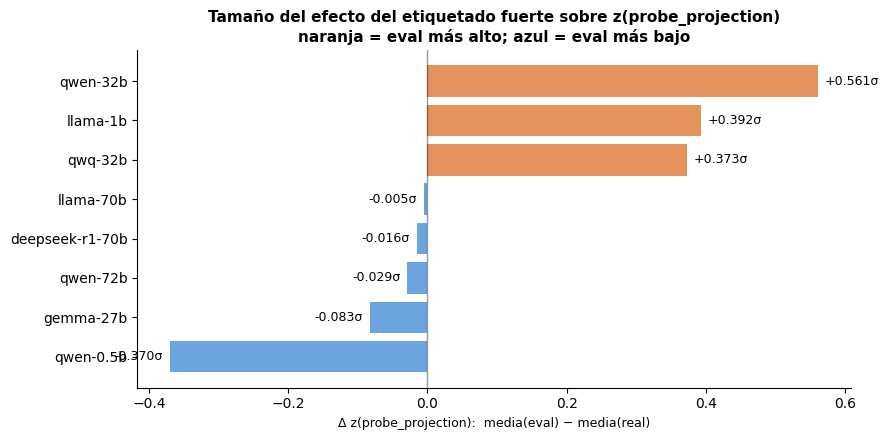


ROC-AUC vs Δz por modelo:
                 delta  roc_auc
model                          
qwen-0.5b       -0.370    0.395
gemma-27b       -0.083    0.458
qwen-72b        -0.029    0.489
deepseek-r1-70b -0.016    0.490
llama-70b       -0.005    0.481
qwq-32b          0.373    0.587
llama-1b         0.392    0.600
qwen-32b         0.561    0.662


In [10]:
# Effect size: mean difference (eval − real) in z-scored projection
effect_rows = []
for model, df in dfs.items():
    mu    = df['probe_projection'].mean()
    sigma = df['probe_projection'].std()
    z     = (df['probe_projection'] - mu) / sigma

    mean_eval = z[df['is_eval']].mean()
    mean_real = z[~df['is_eval']].mean()
    effect_rows.append({
        'model':      model,
        'mean_eval':  mean_eval,
        'mean_real':  mean_real,
        'delta':      mean_eval - mean_real,  # positive → probe scores eval higher
    })

effect_df = pd.DataFrame(effect_rows).set_index('model').sort_values('delta')

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#e07b39' if d > 0 else '#4a90d9' for d in effect_df['delta']]
bars = ax.barh(effect_df.index, effect_df['delta'], color=colors, alpha=0.82, edgecolor='none')

for bar, val in zip(bars, effect_df['delta']):
    offset = 0.01 if val >= 0 else -0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}σ', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=1.0, linestyle='-', alpha=0.4)
ax.set_xlabel('Δ z(probe_projection):  media(eval) − media(real)', fontsize=9)
ax.set_title('Tamaño del efecto del etiquetado fuerte sobre z(probe_projection)\n'
             'naranja = eval más alto; azul = eval más bajo', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()

print("\nROC-AUC vs Δz por modelo:")
print(pd.concat([effect_df[['delta']], metrics_df[['roc_auc']]], axis=1).round(3).to_string())

## Interpretación

### Desbalance de clases
El 92.5% de los prompts del dataset de sensibilidad cumple al menos un criterio de inverosimilitud, por lo que casi todo el dataset queda etiquetado como `is_eval=True`. Esto tiene dos consecuencias:
- Las métricas clásicas (accuracy, recall) son engañosas: el baseline trivial alcanza accuracy=0.925 y recall=1.0 sin aprender nada.
- El **ROC-AUC** sobre `probe_projection` y el **tamaño del efecto Δz** son los indicadores más confiables.

### ¿La sonda detecta los prompts de evaluación (según este criterio)?
- Un **ROC-AUC > 0.5** indica que la proyección de la sonda es monotónicamente más alta (o más baja) para los prompts etiquetados como evaluación.
- Un **Δz positivo** significa que la sonda asigna proyecciones más altas a prompts inverosímiles — consistente con lo que esperaríamos si la sonda captura señales de evaluación relacionadas con la incoherencia de contexto, entidades inventadas, estructura formal o conflictos éticos extremos.
- Un **Δz negativo** (ej. qwen-0.5b) sugiere el comportamiento opuesto: la sonda puntúa más bajo a los prompts inverosímiles, lo que puede deberse a que el probe de ese modelo no generaliza o aprendió una dirección diferente.

### Limitación del etiquetado fuerte
Esta etiqueta asume que *todo* prompt inverosímil es de evaluación y *todo* prompt plausible es de uso real. En la práctica, existen prompts plausibles de evaluación y prompts inverosímiles de uso real. Por eso, incluso un AUC alto no implica que la sonda detecte conscientemente el contexto evaluativo, sino que sus activaciones covarian con las dimensiones de inverosimilitud del dataset.

## Conclusión

Vemos que la medida de evaluation awareness medida mediante probes es ortogonal a la medida de inverosimilitud. Es decir, inverosimilitud **no pareciera ser** un indicador de contexto de evaluación/deployment para estos modelos.

In [ ]:
# Figura para la tesis (fig:inverosimilitud) — AUROC y Δz, todos los modelos
# Exportar como figs/inverosimilitud.pdf
CONTROLS = ['qwen-0.5b', 'llama-1b']
ORDER = ['qwen-72b', 'deepseek-r1-70b', 'qwq-32b', 'qwen-32b', 'llama-70b',
         'gemma-27b', 'llama-1b', 'qwen-0.5b']  # por AUROC de Needham (controles al final)

rows = []
for model in ORDER:
    df = dfs[model]
    z = (df['probe_projection'] - df['probe_projection'].mean()) / df['probe_projection'].std()
    y = df['is_eval'].astype(int).values
    rows.append({
        'model': model,
        'auc':   roc_auc_score(y, df['probe_projection'].values),
        'dz':    z[df['is_eval']].mean() - z[~df['is_eval']].mean(),
    })
fig_df = pd.DataFrame(rows).set_index('model').iloc[::-1]  # barh: mayor AUROC arriba

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: AUROC (línea de azar en 0.5)
bar_colors = ['#9aa7b0' if m in CONTROLS else '#4a90d9' for m in fig_df.index]
ax1.barh(fig_df.index, fig_df['auc'], color=bar_colors, alpha=0.82, edgecolor='none')
ax1.axvline(0.5, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='azar (0.5)')
for y_i, v in enumerate(fig_df['auc']):
    ax1.text(v + 0.005, y_i, f'{v:.3f}', va='center', fontsize=9)
ax1.set_xlim(0, 1)
ax1.set_xlabel('ROC-AUC (proyección vs is_eval)', fontsize=9)
ax1.set_title('Capacidad discriminativa', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Derecha: Δz (media eval − media real)
colors = ['#e07b39' if d > 0 else '#4a90d9' for d in fig_df['dz']]
ax2.barh(fig_df.index, fig_df['dz'], color=colors, alpha=0.82, edgecolor='none')
ax2.axvline(0, color='black', linewidth=1.0, alpha=0.5)
for y_i, v in enumerate(fig_df['dz']):
    ax2.text(v + (0.01 if v >= 0 else -0.01), y_i, f'{v:+.2f}σ',
             va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax2.set_xlabel('Δz: media(eval) − media(real)', fontsize=9)
ax2.set_title('Tamaño del efecto', fontsize=11, fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

fig.suptitle('Proyección vs inverosimilitud narrativa (etiquetado fuerte) — los ocho modelos',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()